In [1]:
import torch
from transformers import AutoModelForCausalLM
from transformers import AutoTokenizer, EsmForMaskedLM
from tokenizers import Tokenizer
import torch.nn.functional as F

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import pickle
import os
import csv

from scipy.stats import spearmanr

/opt/anaconda3/envs/MachLearn/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from plm_compare_progen2 import *
from protein_data import *

In [3]:
with open('/Users/johnhutchens/Desktop/Practicum/Data/Wild_Dictionaries/pg2_ProGym_matrices.pickle',
           'rb') as f:
    pg_dict = pickle.load(f)

In [20]:
keys = list(pg_dict.keys())

In [5]:
def spearman_ignore_nan(a, b):
    mask = ~np.isnan(a) & ~np.isnan(b)
    return spearmanr(a[mask], b[mask])

In [6]:
i=25

x = pg_dict[keys[i]]['DMS']
y = pg_dict[keys[i]]['llr_matrix']
print(x.shape,y.shape)

seq = pg_dict[keys[i]]['sequence']
print(seq)
print(len(seq))

sp_val, p_val = spearman_ignore_nan(x, y)
float(sp_val)

(505, 20) (505, 20)
MGETLGDSPIDPESDSFTDTLSANISQEMTMVDTEMPFWPTNFGISSVDLSVMEDHSHSFDIKPFTTVDFSSISTPHYEDIPFTRTDPVVADYKYDLKLQEYQSAIKVEPASPPYYSEKTQLYNKPHEEPSNSLMAIECRVCGDKASGFHYGVHACEGCKGFFRRTIRLKLIYDRCDLNCRIHKKSRNKCQYCRFQKCLAVGMSHNAIRFGRMPQAEKEKLLAEISSDIDQLNPESADLRALAKHLYDSYIKSFPLTKAKARAILTGKTTDKSPFVIYDMNSLMMGEDKIKFKHITPLQEQSKEVAIRIFQGCQFRSVEAVQEITEYAKSIPGFVNLDLNDQVTLLKYGVHEIIYTMLASLMNKDGVLISEGQGFMTREFLKSLRKPFGDFMEPKFEFAVKFNALELDDSDLAIFIAVIILSGDRPGLLNVKPIEDIQDNLLQALELQLKLNHPESSQLFAKLLQKMTDLRQIVTEHVQLLQVIKKTETDMSLHPLLQEIYKDLY
505


0.6710628241863761

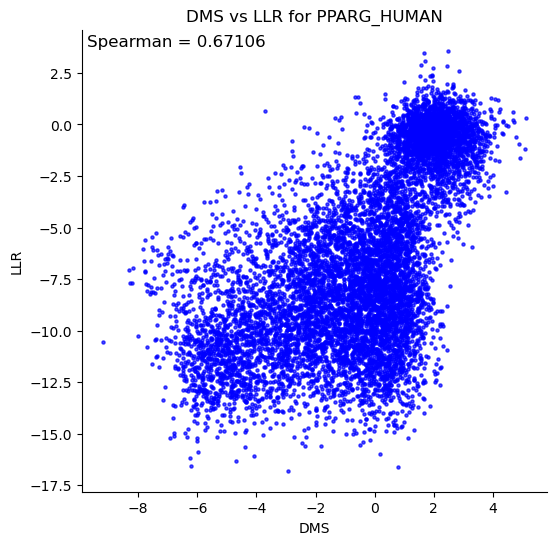

In [7]:
i = 25

x = pg_dict[keys[i]]['DMS']
y = pg_dict[keys[i]]['llr_matrix']

sp_val, p_val = spearman_ignore_nan(x, y)

mask = ~np.isnan(x) & ~np.isnan(y)
x_clean = x[mask]
y_clean = y[mask]


# Scatter plot
plt.figure(figsize=(6, 6))
plt.scatter(x_clean, y_clean, color='blue', alpha=0.7, s=5)
plt.xlabel("DMS")
plt.ylabel("LLR")
plt.title(f"DMS vs LLR for {keys[i]}")
plt.grid(False)
ax = plt.gca()
ax.text(
    0.01, 0.99,                
    f"Spearman = {round(sp_val,5)}",
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment='top',
    horizontalalignment='left',
)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)


plt.show()

In [8]:
len(keys)

186

In [29]:
for i in range(len(keys)):
    key = keys[i]
    if 'llr_matrix' in pg_dict[key].keys():
        x = pg_dict[key]['DMS']
        y = pg_dict[key]['llr_matrix']
        seq = pg_dict[key]['sequence']
        
        sp_val, p_val = spearman_ignore_nan(x, y)
        pg_dict[key]['spearman_DMS'] = (sp_val,p_val)
        
    

In [31]:
pg_dict[keys[20]]['spearman_DMS']

(np.float64(0.2726655554389908), np.float64(1.2072108802610861e-14))

In [ ]:
# path = '/Users/johnhutchens/Desktop/Practicum/Data/Wild_Dictionaries/'
# filename = 'pg2_ProGym_matrices.pickle' 

# with open(path + filename, 'wb') as f:
#     pickle.dump(pg_dict, f, protocol=pickle.HIGHEST_PROTOCOL)

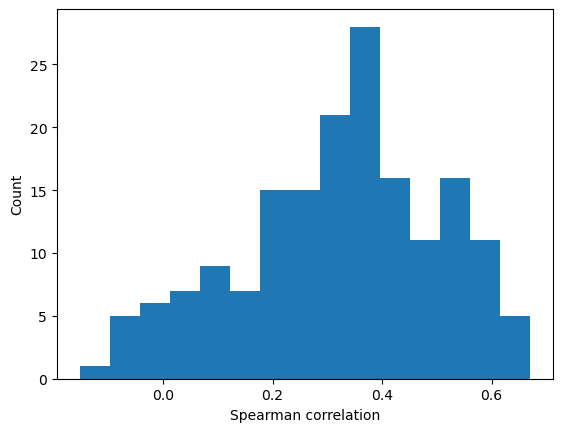

In [28]:
plt.figure()
plt.hist(sp_list, bins=15)
plt.xlabel("Spearman correlation")
plt.ylabel("Count")

plt.show()

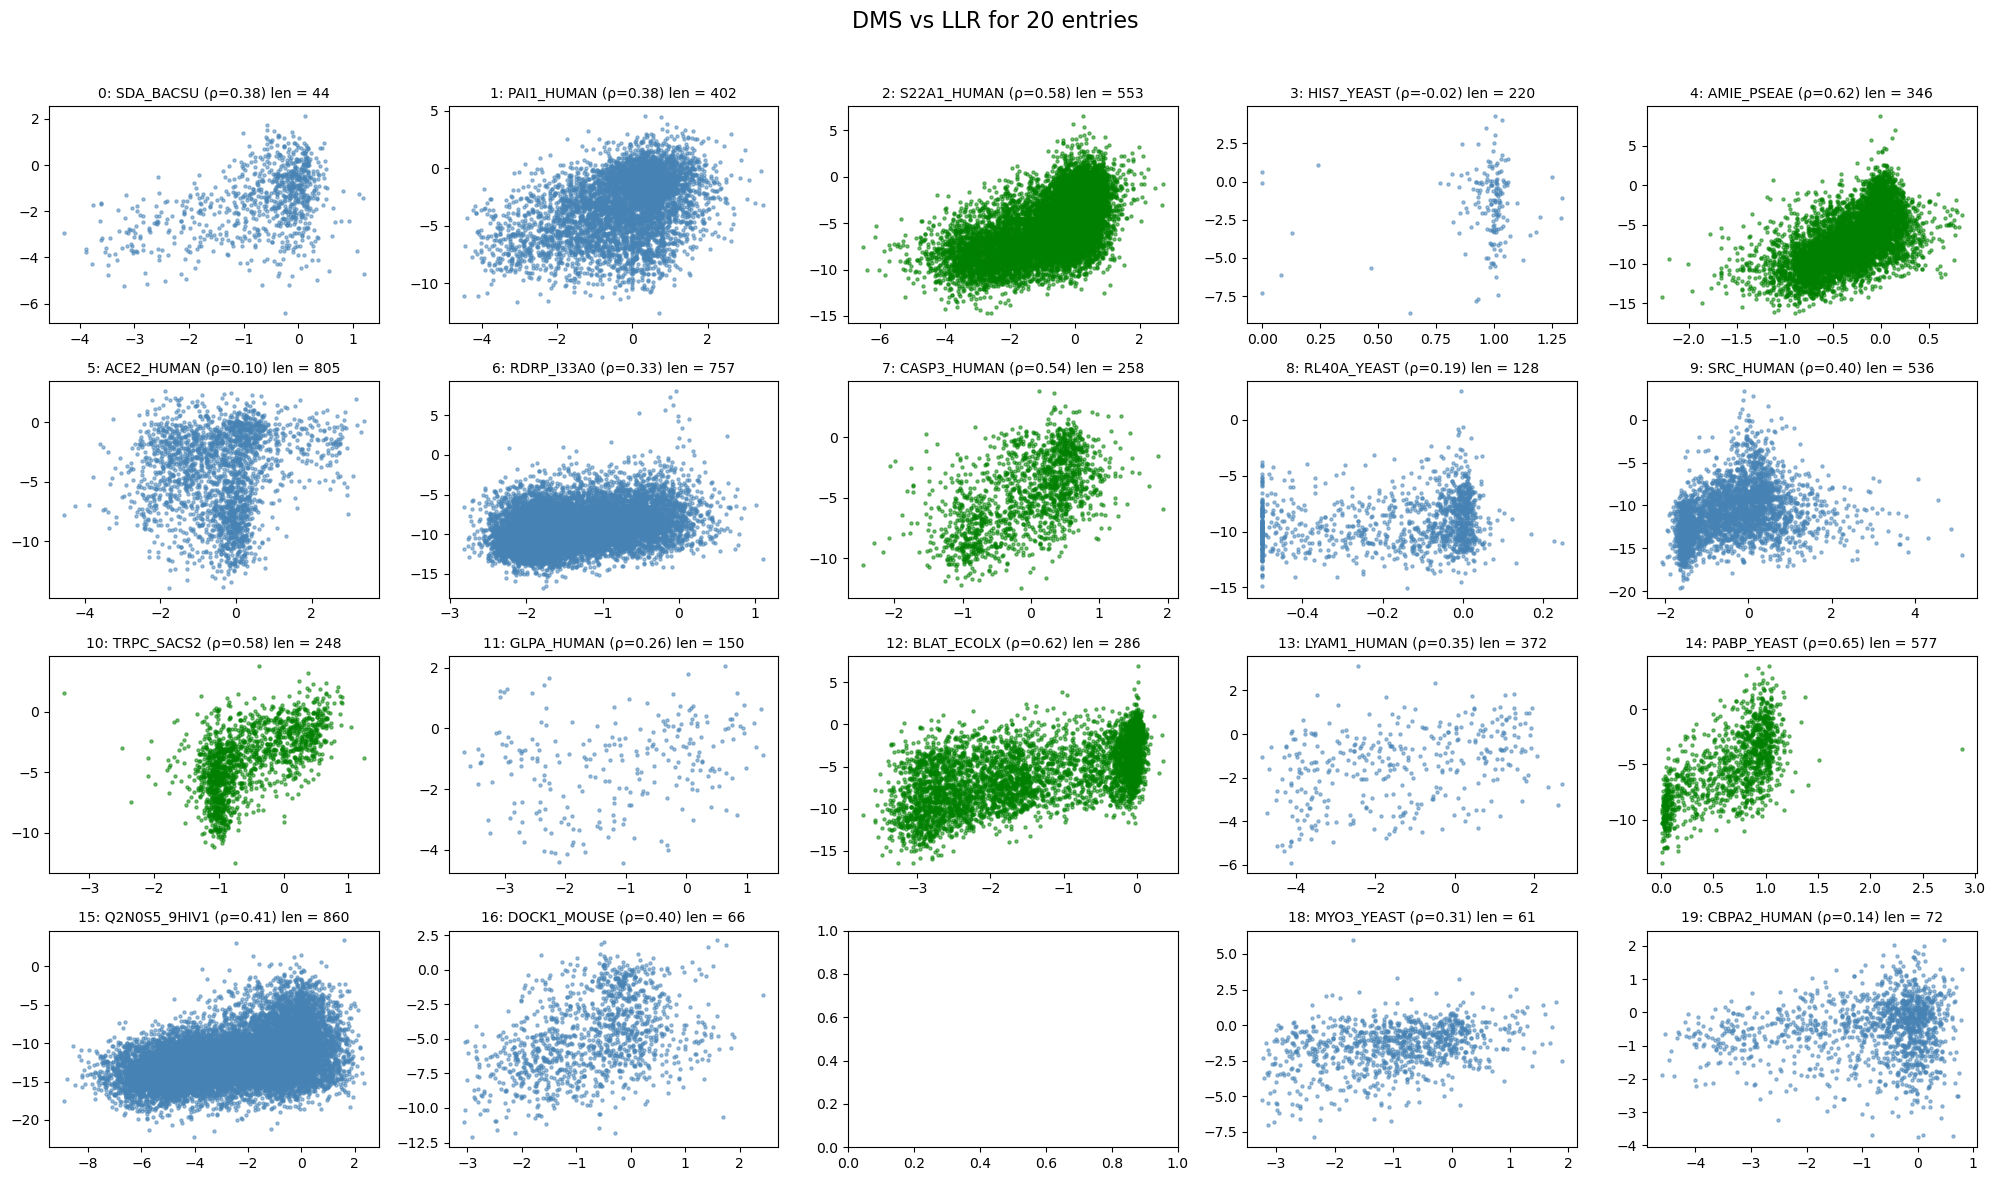

In [ ]:
indices_to_plot = range(20)  
n_plots = len(indices_to_plot)

# Determine grid size (e.g., 4 rows x 5 columns)
n_rows = 4
n_cols = 5

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 12))
axes = axes.flatten()  # flatten for easy indexing

for idx, i in enumerate(indices_to_plot):
    if 'llr_matrix' in pg_dict[keys[i]].keys():
        ax = axes[idx]
        
        x = pg_dict[keys[i]]['DMS']
        y = pg_dict[keys[i]]['llr_matrix']
        seq = pg_dict[keys[i]]['sequence']
        
        sp_val, p_val = spearman_ignore_nan(x, y)
        
        mask = ~np.isnan(x) & ~np.isnan(y)
        x_clean = x[mask]
        y_clean = y[mask]
        
        if sp_val > 0.5:
            ax.scatter(x_clean, y_clean, color='green', alpha=0.5, s=5)
        else:
            ax.scatter(x_clean, y_clean, color='steelblue', alpha=0.5, s=5)
        
        ax.set_title(f'{i}: {keys[i]} (ρ={sp_val:.2f}) len = {len(seq)}', fontsize=10)
        ax.grid(False)
    

# Hide any unused subplots (if grid > n_plots)
for k in range(n_plots, len(axes)):
    axes[k].axis('off')

fig.suptitle("DMS vs LLR for 20 entries", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


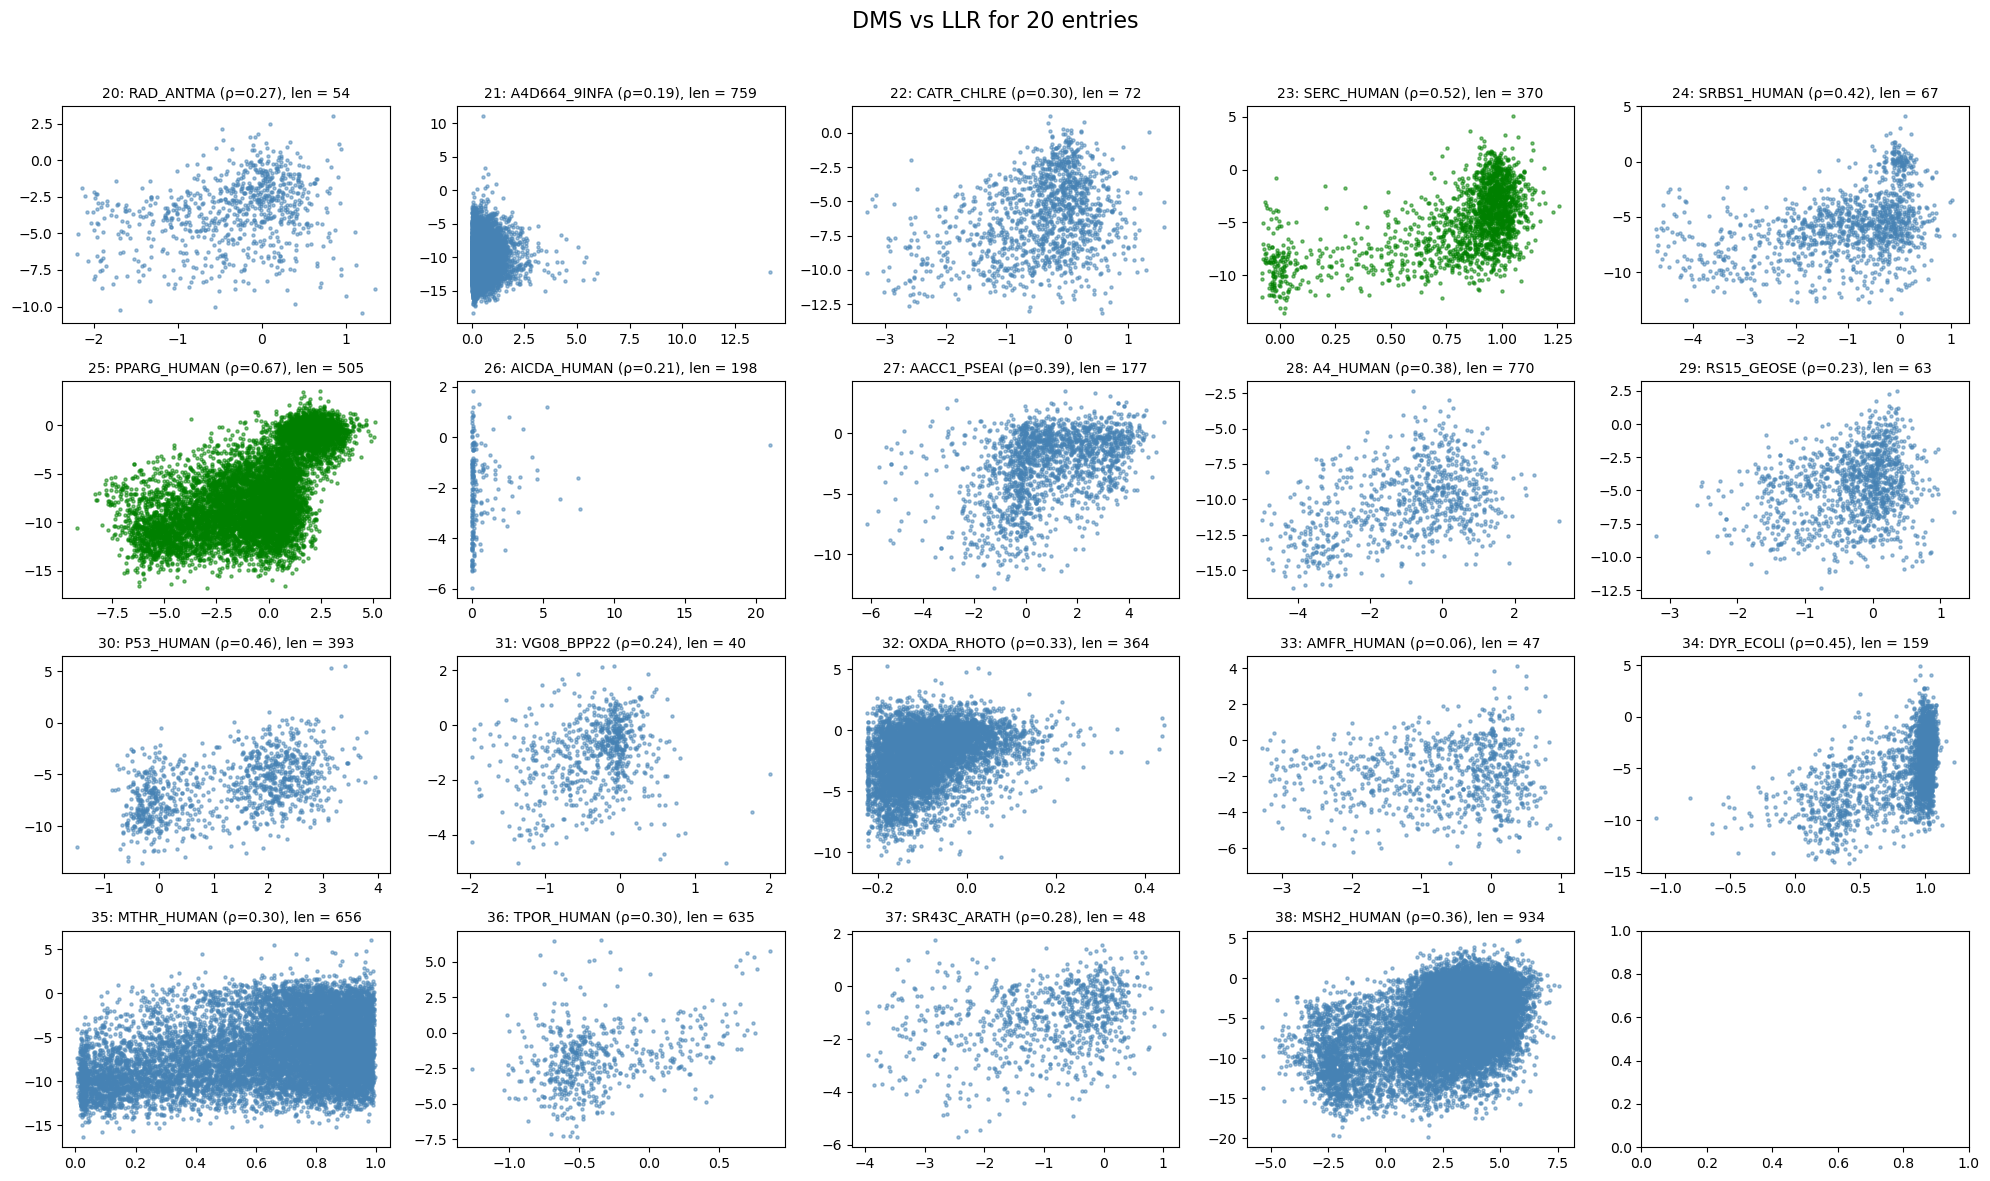

In [10]:
indices_to_plot = range(20,40)  
n_plots = len(indices_to_plot)

# Determine grid size (e.g., 4 rows x 5 columns)
n_rows = 4
n_cols = 5

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 12))
axes = axes.flatten()  # flatten for easy indexing

for idx, i in enumerate(indices_to_plot):
    if 'llr_matrix' in pg_dict[keys[i]].keys():
        ax = axes[idx]
        
        x = pg_dict[keys[i]]['DMS']
        y = pg_dict[keys[i]]['llr_matrix']
        seq = pg_dict[keys[i]]['sequence']
        
        # Spearman correlation ignoring NaNs
        sp_val, p_val = spearman_ignore_nan(x, y)
        
        # Mask to remove NaNs
        mask = ~np.isnan(x) & ~np.isnan(y)
        x_clean = x[mask]
        y_clean = y[mask]
        
        if sp_val > 0.5:
            ax.scatter(x_clean, y_clean, color='green', alpha=0.5, s=5)
        else:
            ax.scatter(x_clean, y_clean, color='steelblue', alpha=0.5, s=5)
        
        ax.set_title(f'{i}: {keys[i]} (ρ={sp_val:.2f}), len = {len(seq)}', fontsize=10)
        ax.grid(False)
    

# Hide any unused subplots (if grid > n_plots)
for k in range(n_plots, len(axes)):
    axes[k].axis('off')

fig.suptitle("DMS vs LLR for 20 entries", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

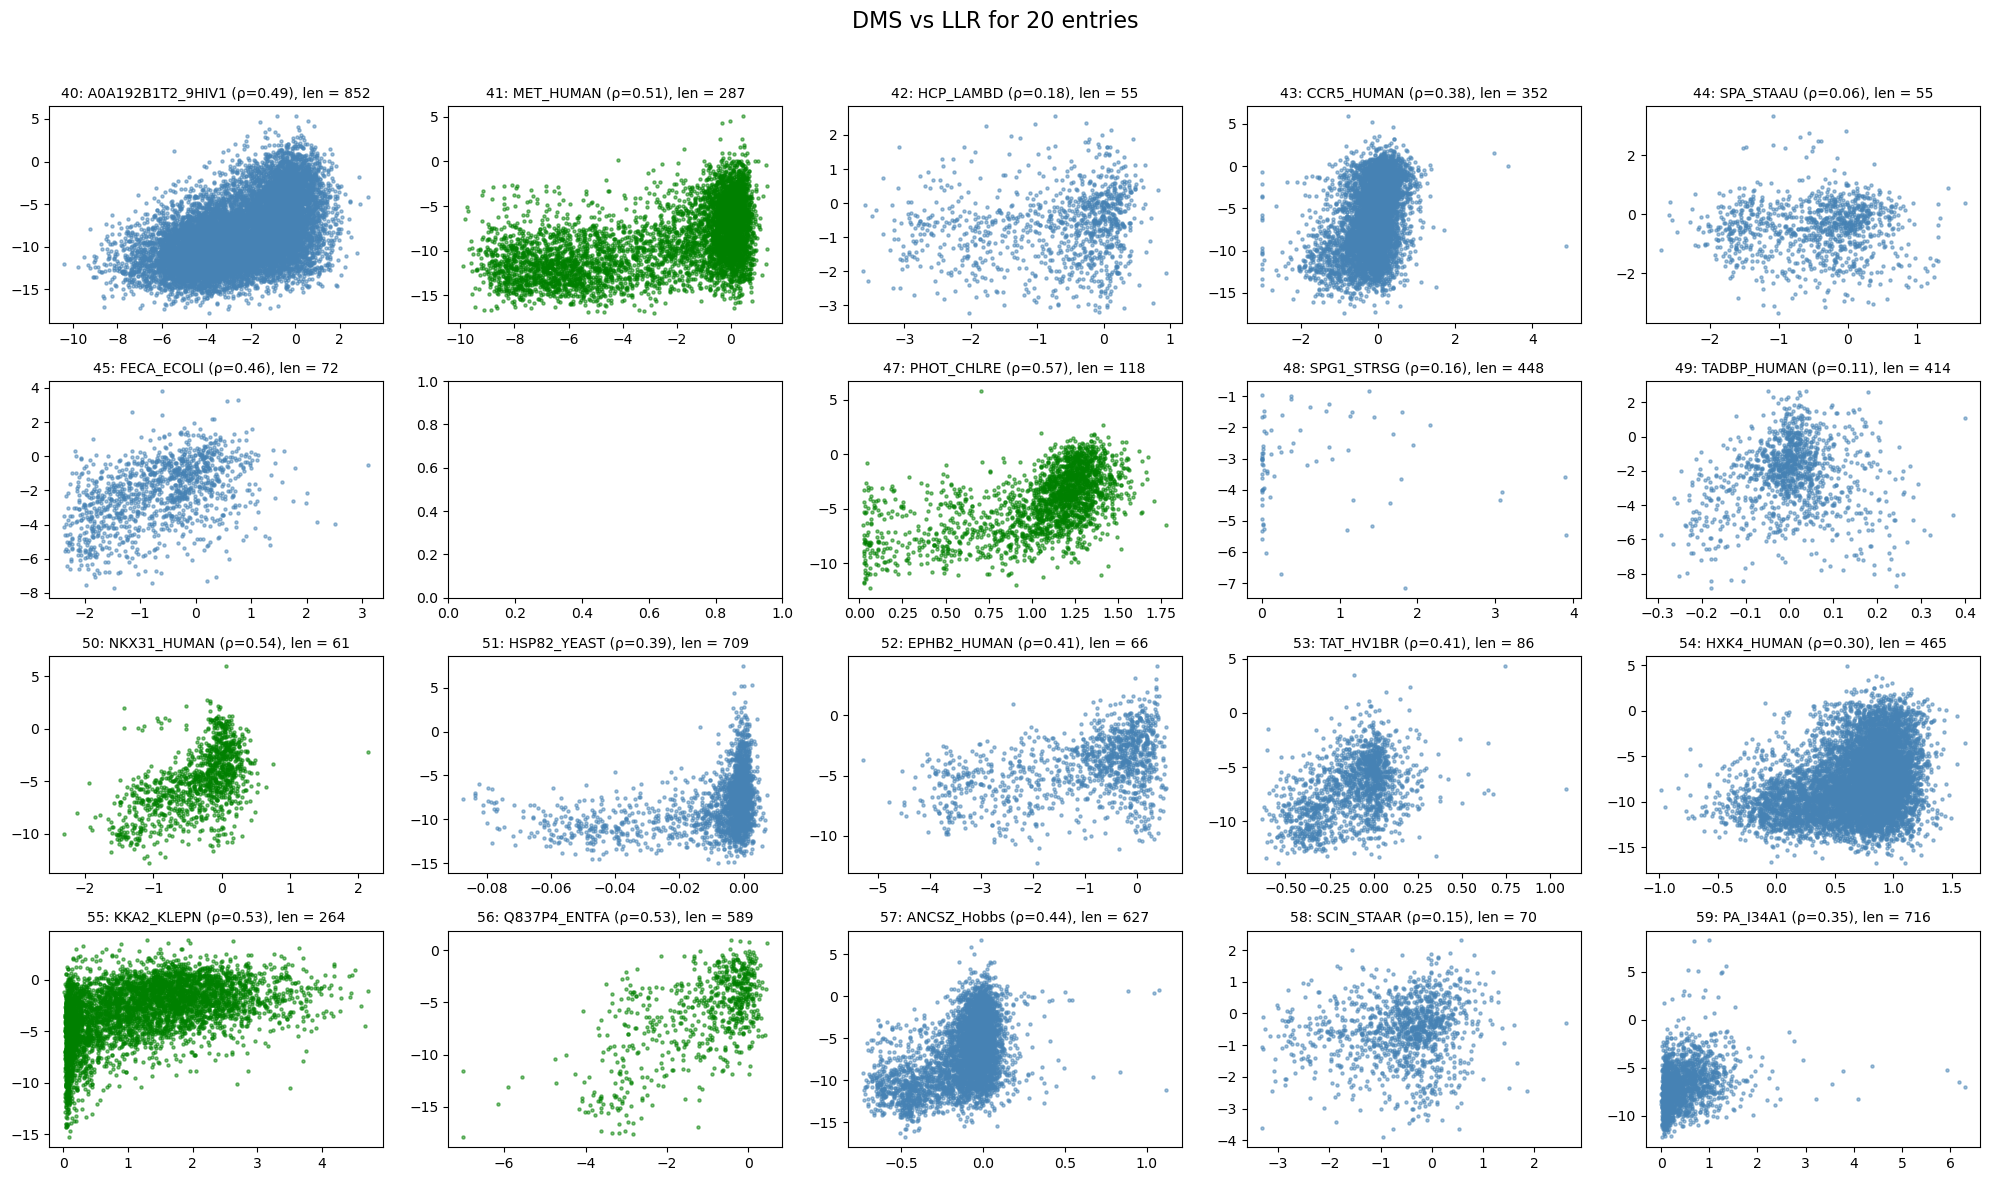

In [11]:
indices_to_plot = range(40,60)  
n_plots = len(indices_to_plot)

# Determine grid size (e.g., 4 rows x 5 columns)
n_rows = 4
n_cols = 5

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 12))
axes = axes.flatten()  # flatten for easy indexing

for idx, i in enumerate(indices_to_plot):
    if 'llr_matrix' in pg_dict[keys[i]].keys():
        ax = axes[idx]
        
        x = pg_dict[keys[i]]['DMS']
        y = pg_dict[keys[i]]['llr_matrix']
        seq = pg_dict[keys[i]]['sequence']
        
        # Spearman correlation ignoring NaNs
        sp_val, p_val = spearman_ignore_nan(x, y)
        
        # Mask to remove NaNs
        mask = ~np.isnan(x) & ~np.isnan(y)
        x_clean = x[mask]
        y_clean = y[mask]
        
        if sp_val > 0.5:
            ax.scatter(x_clean, y_clean, color='green', alpha=0.5, s=5)
        else:
            ax.scatter(x_clean, y_clean, color='steelblue', alpha=0.5, s=5)
        
        ax.set_title(f'{i}: {keys[i]} (ρ={sp_val:.2f}), len = {len(seq)}', fontsize=10)
        ax.grid(False)
    

# Hide any unused subplots (if grid > n_plots)
for k in range(n_plots, len(axes)):
    axes[k].axis('off')

fig.suptitle("DMS vs LLR for 20 entries", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

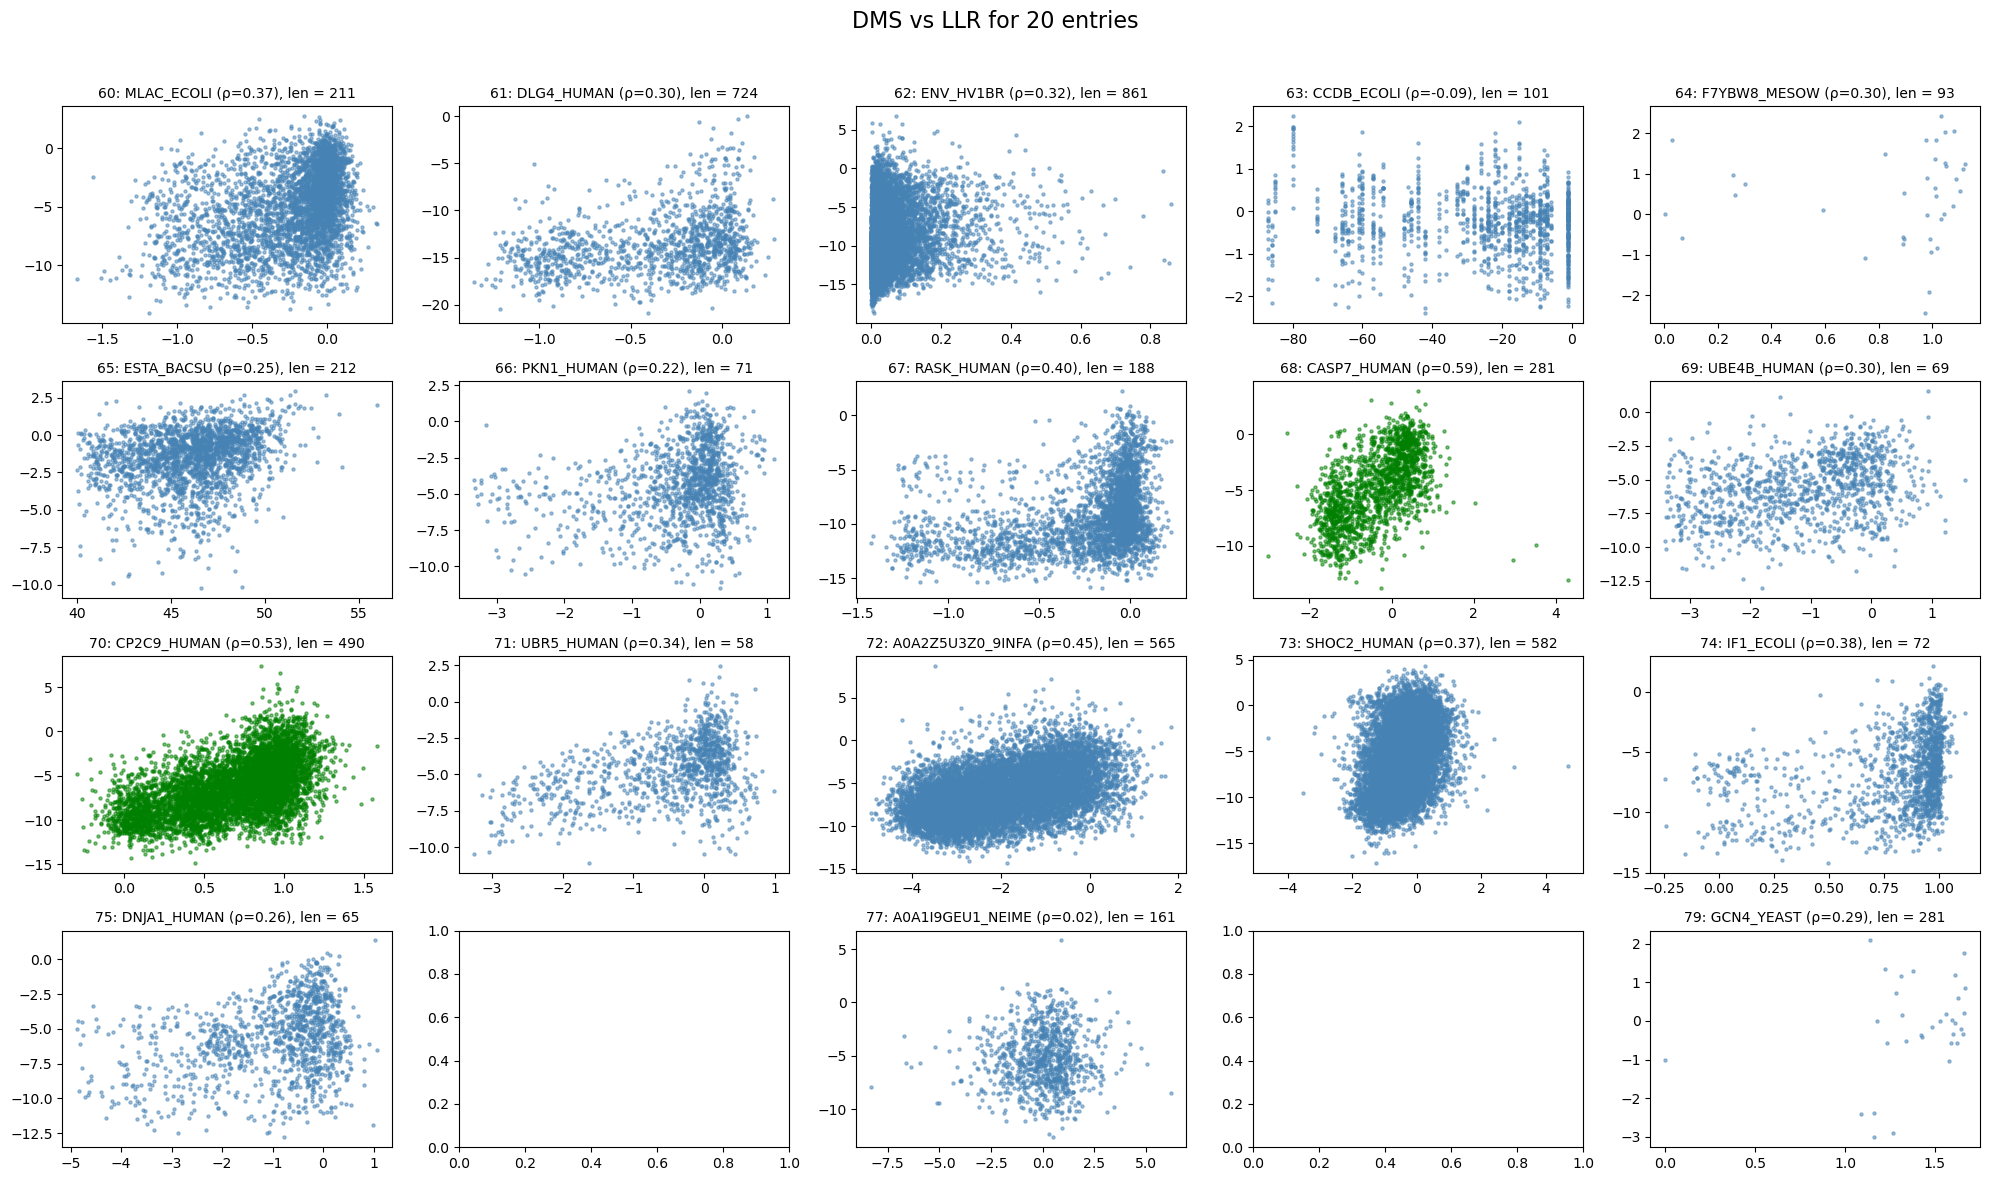

In [12]:
indices_to_plot = range(60,80)  
n_plots = len(indices_to_plot)

# Determine grid size (e.g., 4 rows x 5 columns)
n_rows = 4
n_cols = 5

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 12))
axes = axes.flatten()  # flatten for easy indexing

for idx, i in enumerate(indices_to_plot):
    if 'llr_matrix' in pg_dict[keys[i]].keys():
        ax = axes[idx]
        
        x = pg_dict[keys[i]]['DMS']
        y = pg_dict[keys[i]]['llr_matrix']
        seq = pg_dict[keys[i]]['sequence']
        
        # Spearman correlation ignoring NaNs
        sp_val, p_val = spearman_ignore_nan(x, y)
        
        # Mask to remove NaNs
        mask = ~np.isnan(x) & ~np.isnan(y)
        x_clean = x[mask]
        y_clean = y[mask]
        
        if sp_val > 0.5:
            ax.scatter(x_clean, y_clean, color='green', alpha=0.5, s=5)
        else:
            ax.scatter(x_clean, y_clean, color='steelblue', alpha=0.5, s=5)
        
        ax.set_title(f'{i}: {keys[i]} (ρ={sp_val:.2f}), len = {len(seq)}', fontsize=10)
        ax.grid(False)
    

# Hide any unused subplots (if grid > n_plots)
for k in range(n_plots, len(axes)):
    axes[k].axis('off')

fig.suptitle("DMS vs LLR for 20 entries", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

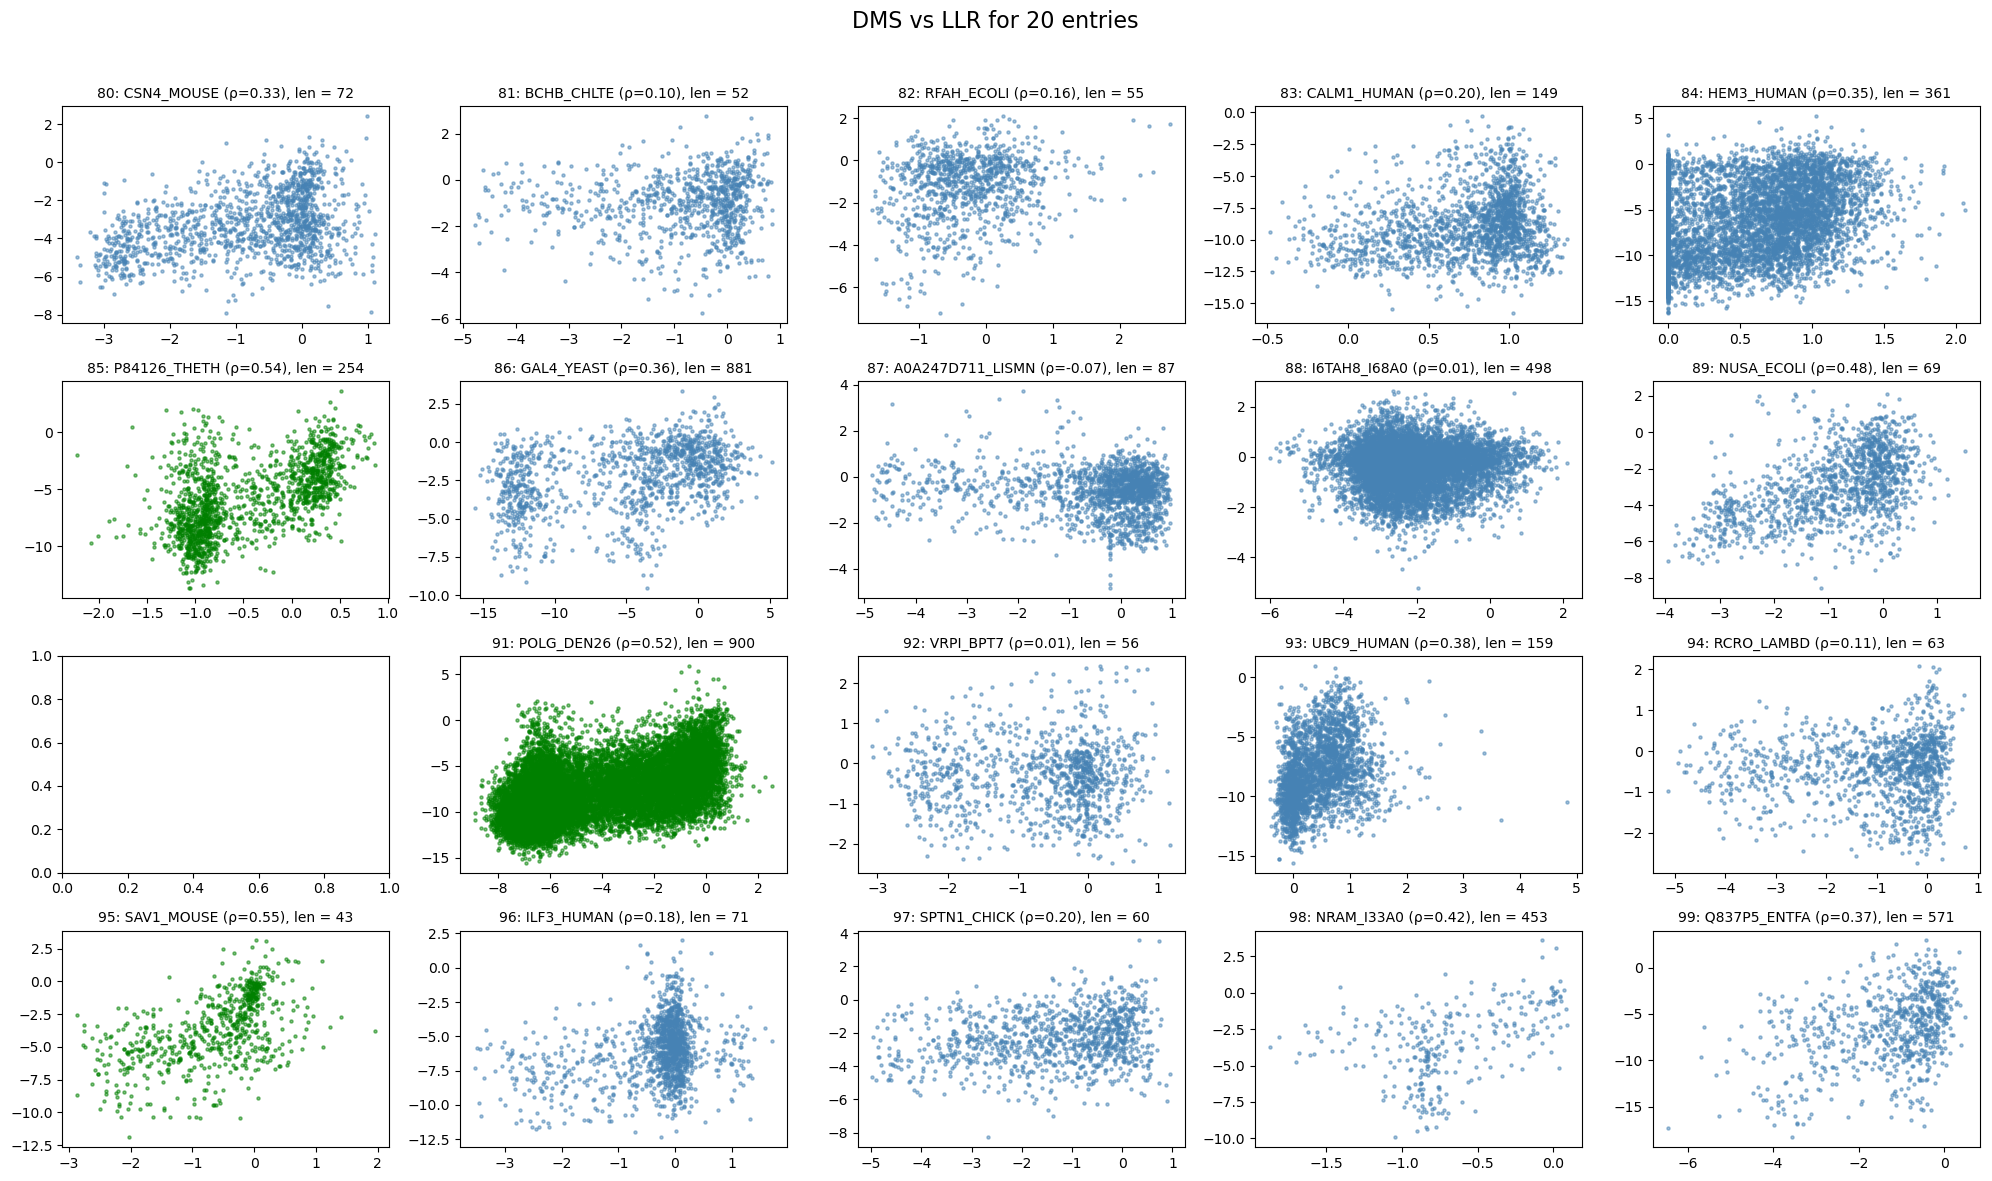

In [13]:
indices_to_plot = range(80,100)  
n_plots = len(indices_to_plot)

# Determine grid size (e.g., 4 rows x 5 columns)
n_rows = 4
n_cols = 5

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 12))
axes = axes.flatten()  # flatten for easy indexing

for idx, i in enumerate(indices_to_plot):
    if 'llr_matrix' in pg_dict[keys[i]].keys():
        ax = axes[idx]
        
        x = pg_dict[keys[i]]['DMS']
        y = pg_dict[keys[i]]['llr_matrix']
        seq = pg_dict[keys[i]]['sequence']
        
        # Spearman correlation ignoring NaNs
        sp_val, p_val = spearman_ignore_nan(x, y)
        
        # Mask to remove NaNs
        mask = ~np.isnan(x) & ~np.isnan(y)
        x_clean = x[mask]
        y_clean = y[mask]
        
        if sp_val > 0.5:
            ax.scatter(x_clean, y_clean, color='green', alpha=0.5, s=5)
        else:
            ax.scatter(x_clean, y_clean, color='steelblue', alpha=0.5, s=5)
        
        ax.set_title(f'{i}: {keys[i]} (ρ={sp_val:.2f}), len = {len(seq)}', fontsize=10)
        ax.grid(False)
    

# Hide any unused subplots (if grid > n_plots)
for k in range(n_plots, len(axes)):
    axes[k].axis('off')

fig.suptitle("DMS vs LLR for 20 entries", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

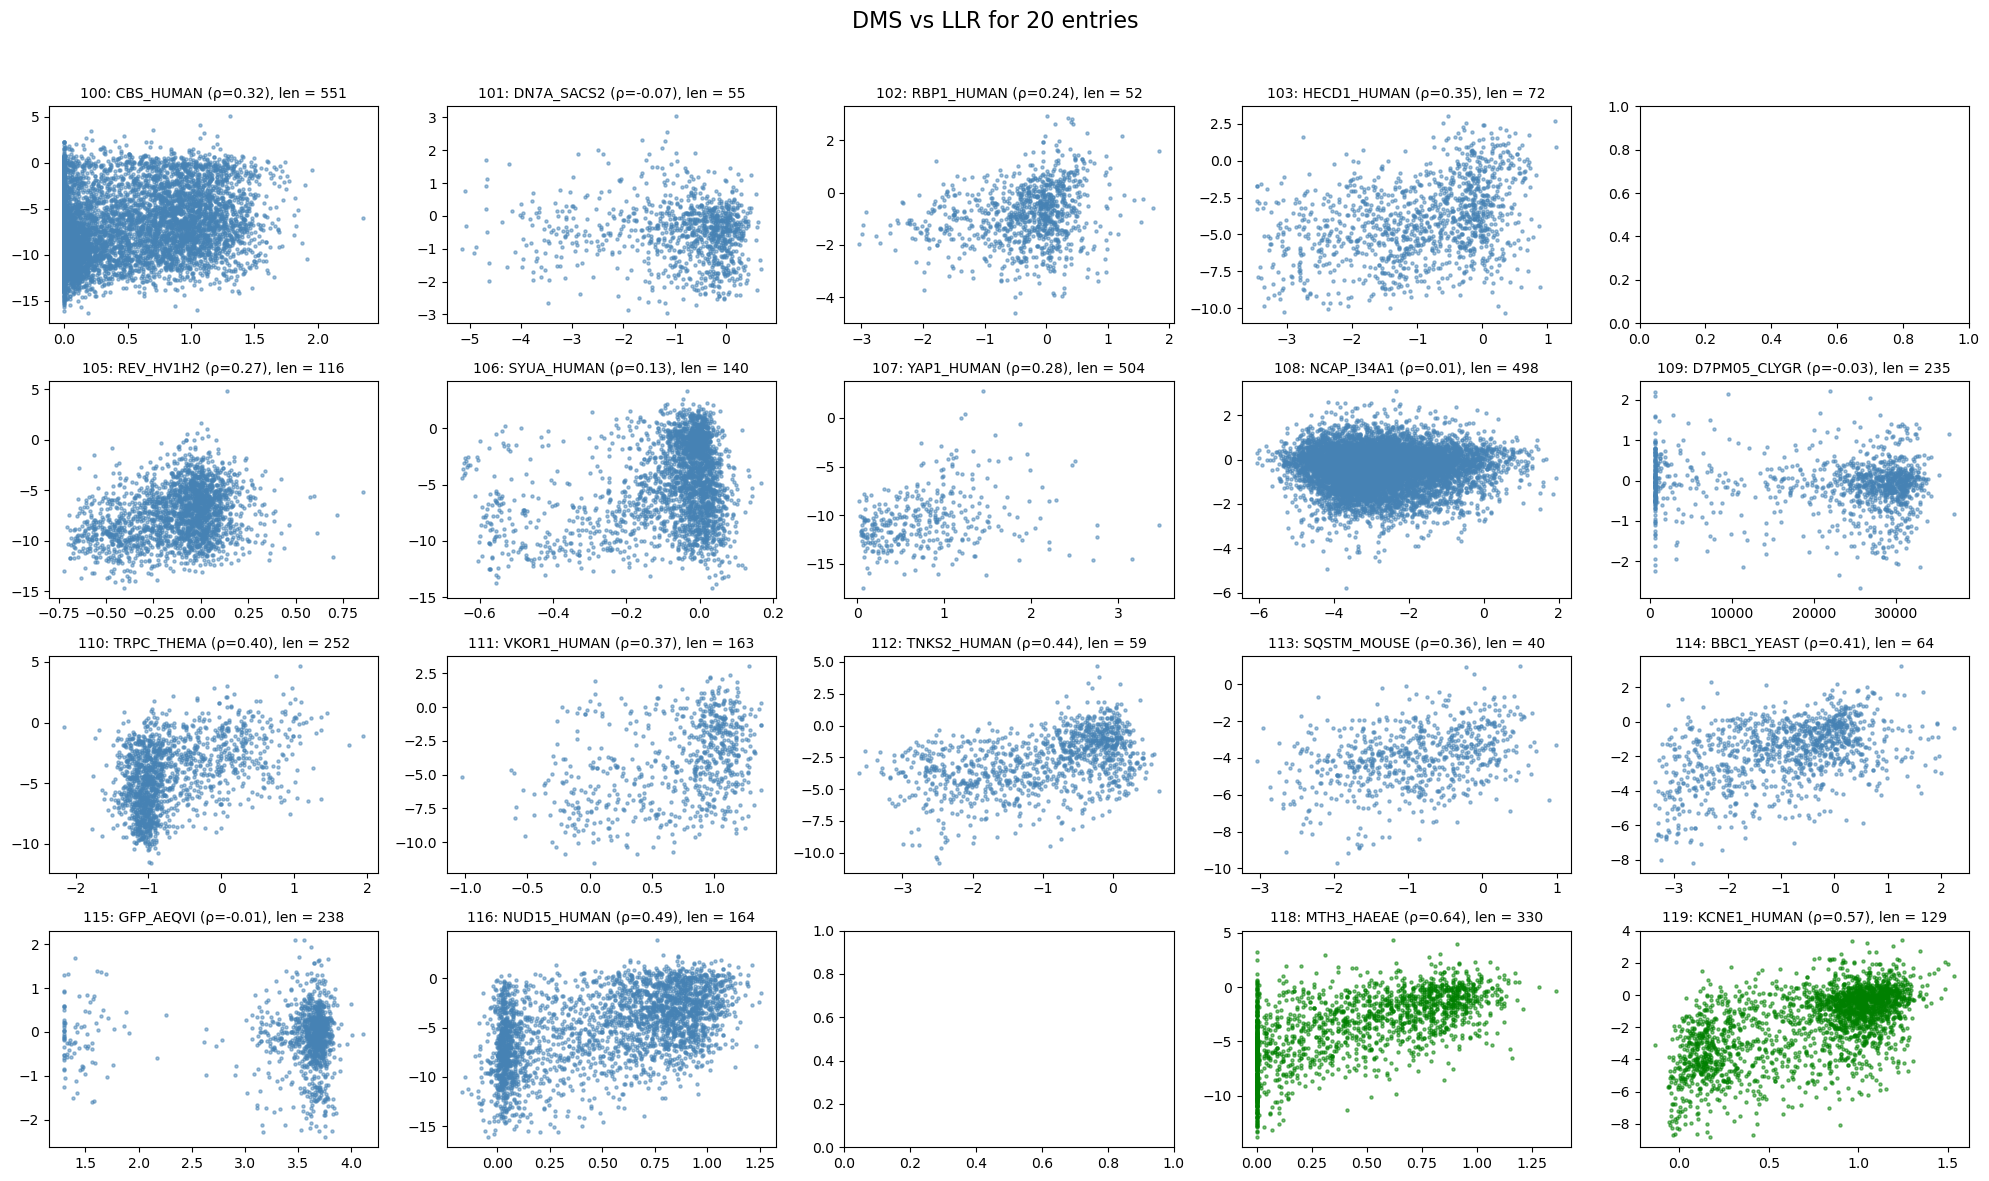

In [14]:
indices_to_plot = range(100,120)  
n_plots = len(indices_to_plot)

# Determine grid size (e.g., 4 rows x 5 columns)
n_rows = 4
n_cols = 5

# fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 12), sharex=True, sharey=True)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 12))
axes = axes.flatten()  # flatten for easy indexing

for idx, i in enumerate(indices_to_plot):
    if 'llr_matrix' in pg_dict[keys[i]].keys():
        ax = axes[idx]
        
        x = pg_dict[keys[i]]['DMS']
        y = pg_dict[keys[i]]['llr_matrix']
        seq = pg_dict[keys[i]]['sequence']
        
        # Spearman correlation ignoring NaNs
        sp_val, p_val = spearman_ignore_nan(x, y)
        
        # Mask to remove NaNs
        mask = ~np.isnan(x) & ~np.isnan(y)
        x_clean = x[mask]
        y_clean = y[mask]
        
        if sp_val > 0.5:
            ax.scatter(x_clean, y_clean, color='green', alpha=0.5, s=5)
        else:
            ax.scatter(x_clean, y_clean, color='steelblue', alpha=0.5, s=5)
        
        ax.set_title(f'{i}: {keys[i]} (ρ={sp_val:.2f}), len = {len(seq)}', fontsize=10)
        ax.grid(False)
    

# Hide any unused subplots (if grid > n_plots)
for k in range(n_plots, len(axes)):
    axes[k].axis('off')

fig.suptitle("DMS vs LLR for 20 entries", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

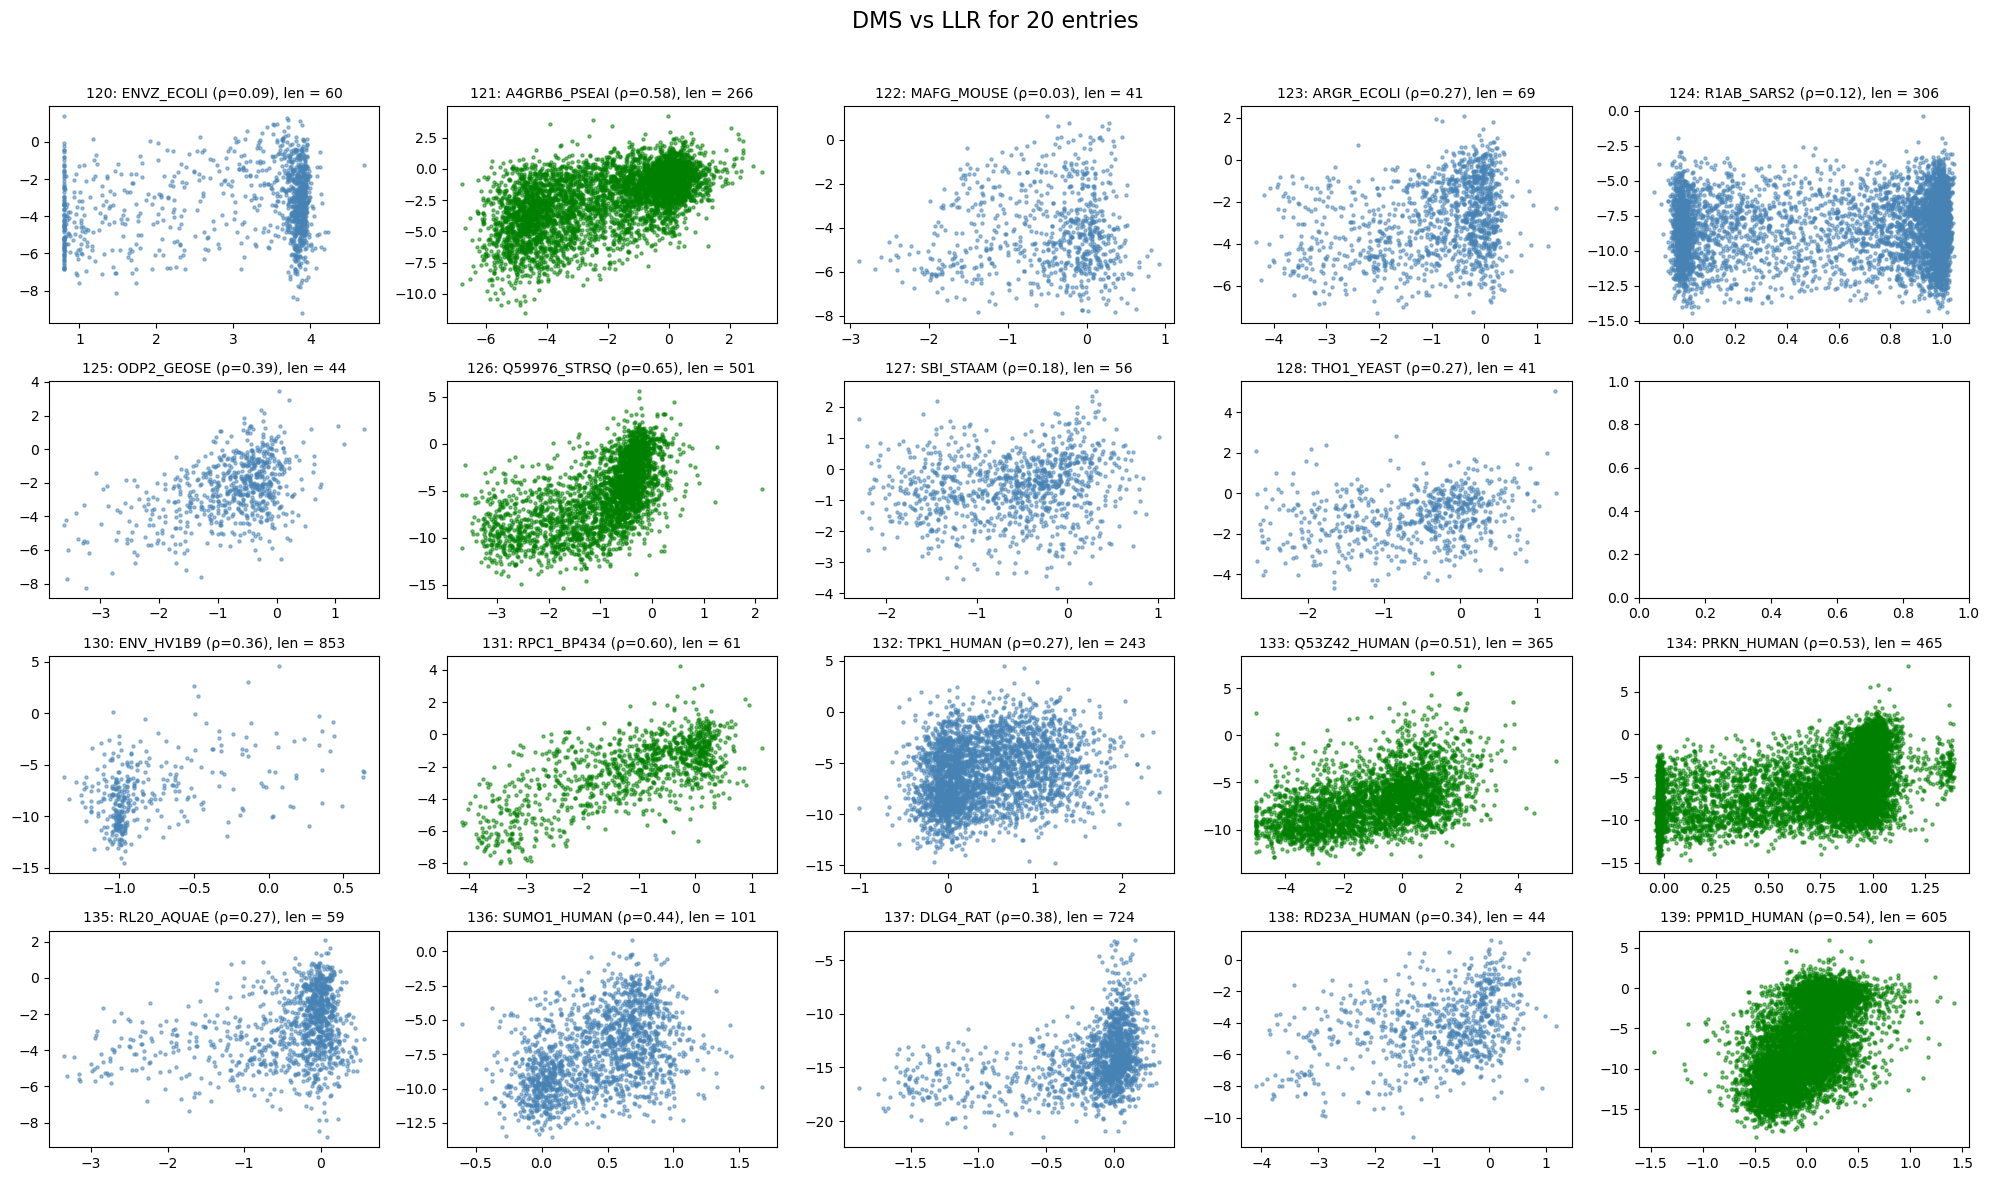

In [15]:
indices_to_plot = range(120,140)  
n_plots = len(indices_to_plot)

# Determine grid size (e.g., 4 rows x 5 columns)
n_rows = 4
n_cols = 5

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 12))
axes = axes.flatten()  # flatten for easy indexing

for idx, i in enumerate(indices_to_plot):
    if 'llr_matrix' in pg_dict[keys[i]].keys():
        ax = axes[idx]
        
        x = pg_dict[keys[i]]['DMS']
        y = pg_dict[keys[i]]['llr_matrix']
        seq = pg_dict[keys[i]]['sequence']
        
        # Spearman correlation ignoring NaNs
        sp_val, p_val = spearman_ignore_nan(x, y)
        
        # Mask to remove NaNs
        mask = ~np.isnan(x) & ~np.isnan(y)
        x_clean = x[mask]
        y_clean = y[mask]
        
        if sp_val > 0.5:
            ax.scatter(x_clean, y_clean, color='green', alpha=0.5, s=5)
        else:
            ax.scatter(x_clean, y_clean, color='steelblue', alpha=0.5, s=5)
        
        ax.set_title(f'{i}: {keys[i]} (ρ={sp_val:.2f}), len = {len(seq)}', fontsize=10)
        ax.grid(False)
    

# Hide any unused subplots (if grid > n_plots)
for k in range(n_plots, len(axes)):
    axes[k].axis('off')

fig.suptitle("DMS vs LLR for 20 entries", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

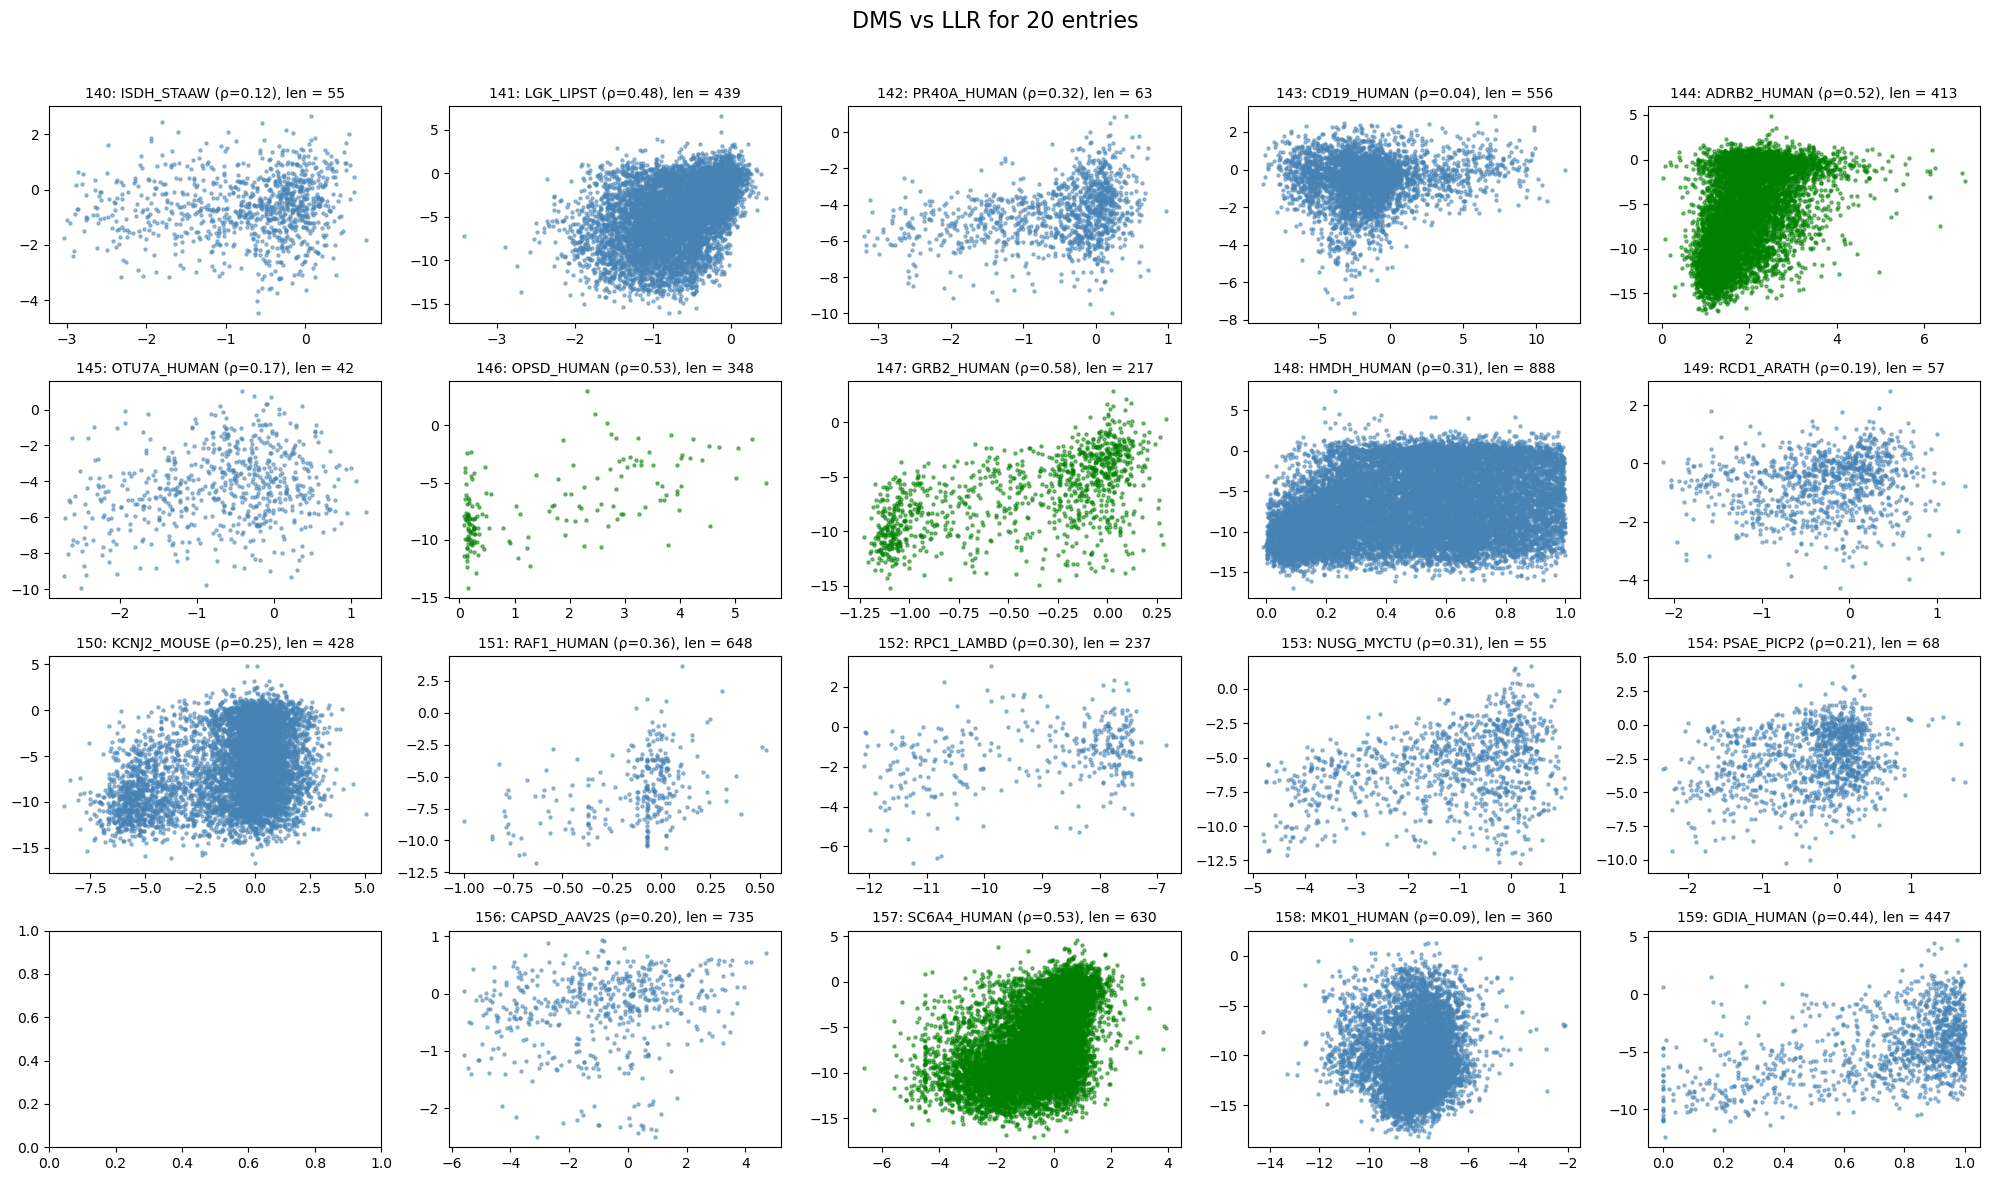

In [16]:
indices_to_plot = range(140,160)  
n_plots = len(indices_to_plot)

# Determine grid size (e.g., 4 rows x 5 columns)
n_rows = 4
n_cols = 5

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 12))
axes = axes.flatten()  # flatten for easy indexing

for idx, i in enumerate(indices_to_plot):
    if 'llr_matrix' in pg_dict[keys[i]].keys():
        ax = axes[idx]
        
        x = pg_dict[keys[i]]['DMS']
        y = pg_dict[keys[i]]['llr_matrix']
        seq = pg_dict[keys[i]]['sequence']
        
        # Spearman correlation ignoring NaNs
        sp_val, p_val = spearman_ignore_nan(x, y)
        
        # Mask to remove NaNs
        mask = ~np.isnan(x) & ~np.isnan(y)
        x_clean = x[mask]
        y_clean = y[mask]
        
        if sp_val > 0.5:
            ax.scatter(x_clean, y_clean, color='green', alpha=0.5, s=5)
        else:
            ax.scatter(x_clean, y_clean, color='steelblue', alpha=0.5, s=5)
        
        ax.set_title(f'{i}: {keys[i]} (ρ={sp_val:.2f}), len = {len(seq)}', fontsize=10)
        ax.grid(False)
    

# Hide any unused subplots (if grid > n_plots)
for k in range(n_plots, len(axes)):
    axes[k].axis('off')

fig.suptitle("DMS vs LLR for 20 entries", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

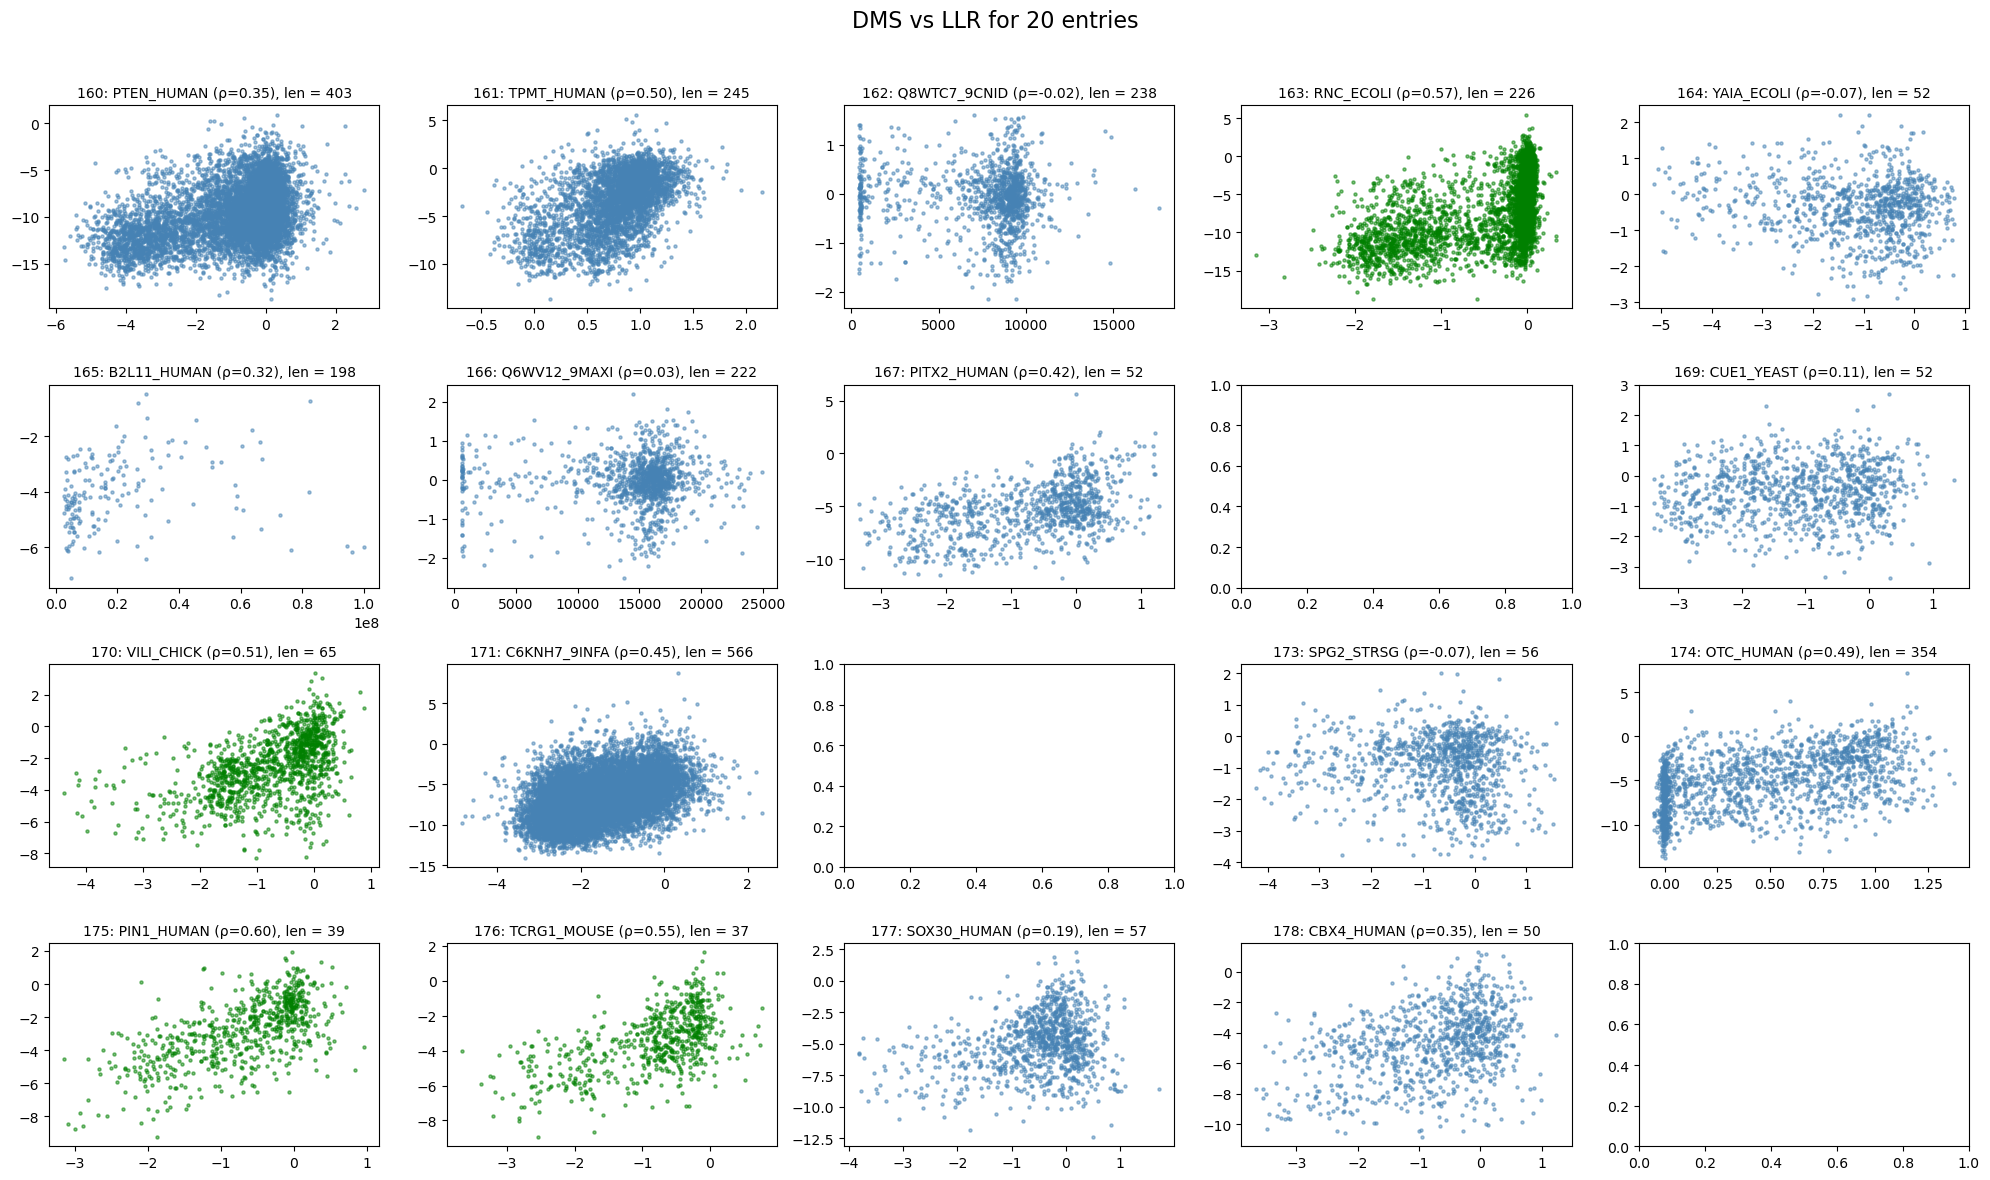

In [17]:
indices_to_plot = range(160,180)  
n_plots = len(indices_to_plot)

# Determine grid size (e.g., 4 rows x 5 columns)
n_rows = 4
n_cols = 5

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 12))
axes = axes.flatten()  # flatten for easy indexing

for idx, i in enumerate(indices_to_plot):
    if 'llr_matrix' in pg_dict[keys[i]].keys():
        ax = axes[idx]
        
        x = pg_dict[keys[i]]['DMS']
        y = pg_dict[keys[i]]['llr_matrix']
        seq = pg_dict[keys[i]]['sequence']
        
        # Spearman correlation ignoring NaNs
        sp_val, p_val = spearman_ignore_nan(x, y)
        
        # Mask to remove NaNs
        mask = ~np.isnan(x) & ~np.isnan(y)
        x_clean = x[mask]
        y_clean = y[mask]
        
        if sp_val > 0.5:
            ax.scatter(x_clean, y_clean, color='green', alpha=0.5, s=5)
        else:
            ax.scatter(x_clean, y_clean, color='steelblue', alpha=0.5, s=5)
        
        ax.set_title(f'{i}: {keys[i]} (ρ={sp_val:.2f}), len = {len(seq)}', fontsize=10)
        ax.grid(False)
    

# Hide any unused subplots (if grid > n_plots)
for k in range(n_plots, len(axes)):
    axes[k].axis('off')

fig.suptitle("DMS vs LLR for 20 entries", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

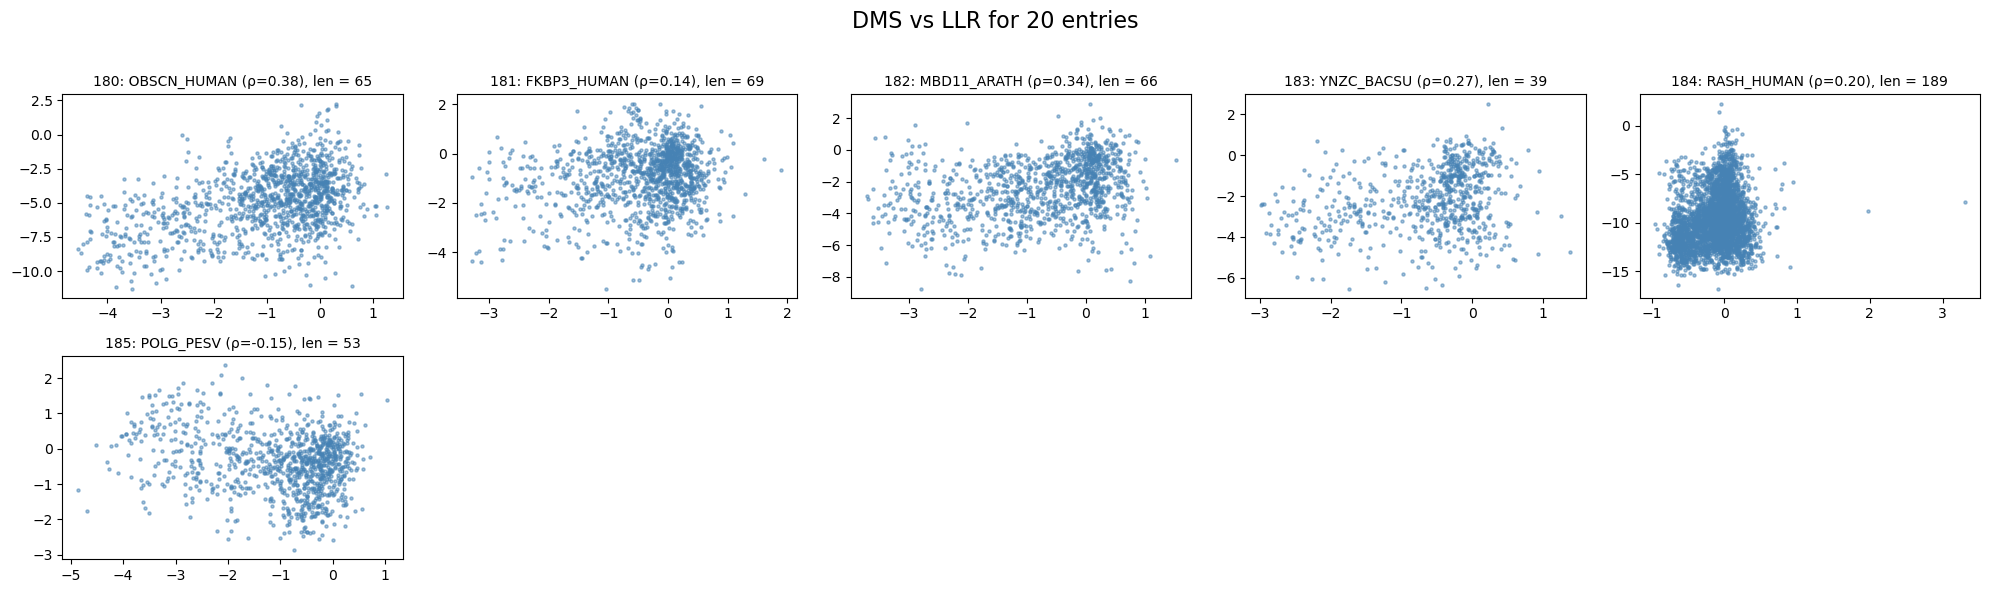

In [18]:
indices_to_plot = range(180,186)  
n_plots = len(indices_to_plot)

# Determine grid size (e.g., 4 rows x 5 columns)
n_rows = 2
n_cols = 5

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 6))
axes = axes.flatten()  # flatten for easy indexing

for idx, i in enumerate(indices_to_plot):
    if 'llr_matrix' in pg_dict[keys[i]].keys():
        ax = axes[idx]
        
        x = pg_dict[keys[i]]['DMS']
        y = pg_dict[keys[i]]['llr_matrix']
        seq = pg_dict[keys[i]]['sequence']
        
        # Spearman correlation ignoring NaNs
        sp_val, p_val = spearman_ignore_nan(x, y)
        
        # Mask to remove NaNs
        mask = ~np.isnan(x) & ~np.isnan(y)
        x_clean = x[mask]
        y_clean = y[mask]
        
        if sp_val > 0.5:
            ax.scatter(x_clean, y_clean, color='green', alpha=0.5, s=5)
        else:
            ax.scatter(x_clean, y_clean, color='steelblue', alpha=0.5, s=5)
        
        ax.set_title(f'{i}: {keys[i]} (ρ={sp_val:.2f}), len = {len(seq)}', fontsize=10)
        ax.grid(False)
    

# Hide any unused subplots (if grid > n_plots)
for k in range(n_plots, len(axes)):
    axes[k].axis('off')

fig.suptitle("DMS vs LLR for 20 entries", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()